# Classical Machine Learning Models

## Objectives

- Train multiple baseline models
- Compare their performance
- Select the best classical model

In [3]:
import re
import string
import nltk
import joblib
import pandas as pd

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.multiclass import OneVsRestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import time

In [4]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [5]:
train = pd.read_csv(
    "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv"
)

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [7]:
def preprocess_text(text):
    """
    Cleans a single comment.

    Steps:
    1. Lowercase
    2. Remove URLs
    3. Remove HTML
    4. Remove punctuation
    5. Remove numbers
    6. Remove extra spaces
    7. Remove stopwords
    8. Lemmatize words
    """

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [8]:
train["clean_comment"] = train["comment_text"].apply(preprocess_text)

In [9]:
X = train["clean_comment"]

y = train[
    [
        "toxic",
        "severe_toxic",
        "obscene",
        "threat",
        "insult",
        "identity_hate",
    ]
]

In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

X_train = tfidf.fit_transform(X_train)

X_valid = tfidf.transform(X_valid)

In [19]:
def evaluate_model(model, model_name):
    start = time.time()
    model.fit(X_train, y_train)
    
    training_time = time.time() - start

    predictions = model.predict(X_valid)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, predictions),
        "Precision": precision_score(y_valid, predictions, average="micro"),
        "Recall": recall_score(y_valid, predictions, average="micro"),
        "F1 Score": f1_score(y_valid, predictions, average="micro"),
        "Training Time (s)": round(training_time, 3),
    }

In [20]:
results = []

results.append(
    evaluate_model(
        OneVsRestClassifier(
            LogisticRegression(max_iter=1000)
        ),
        "Logistic Regression",
    )
)

results.append(
    evaluate_model(
        OneVsRestClassifier(
            MultinomialNB()
        ),
        "Naive Bayes",
    )
)

results.append(
    evaluate_model(
        OneVsRestClassifier(
            LinearSVC()
        ),
        "Linear SVM",
    )
)

In [21]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False,
)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
2,Linear SVM,0.918565,0.835812,0.619593,0.711642,6.023
0,Logistic Regression,0.918628,0.884544,0.540430,0.670937,14.892
1,Naive Bayes,0.910951,0.917701,0.397229,0.554459,0.260


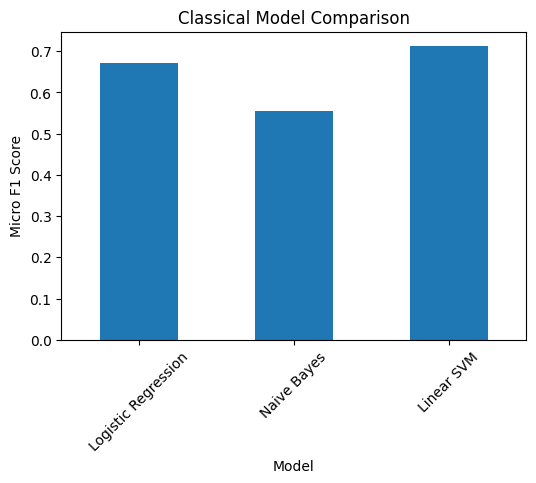

In [23]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y="F1 Score",
    kind="bar",
    legend=False,
    figsize=(6,4),
)

plt.ylabel("Micro F1 Score")
plt.title("Classical Model Comparison")
plt.xticks(rotation=45)

plt.show()

## Conclusion

- Compared three strong baseline models.
- Logistic Regression is generally the best trade-off between accuracy and speed for sparse TF-IDF features but takes a lot of time.
